![](https://www.soyhenry.com/_next/static/media/HenryLogo.bb57fd6f.svg)

# Clase 05: RNN, LSTM, GRU y CNNs temporales

profesor [Carlos Daniel Jiménez](danieljimenez88m@gmail.com)


Las secuencias exigen un modelo que use orden y contexto. Esta clase muestra por que aparecieron las RNNs, por que hicieron falta compuertas como LSTM y GRU, y por que una CNN temporal puede competir cuando la dependencia relevante es local o de mediano alcance.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset


from tools.notebook_utils import choose_value, configure_runtime
from tools.text_corpus import build_vocabulary, load_corpus_text, simple_tokenize

runtime = configure_runtime(seed=29)
print(runtime.summary())
        


seed=29 | smoke=False | online_mode=False | device=mps


## Por que aparecieron las compuertas

Una RNN simple acumula informacion paso a paso, pero cuando la secuencia crece puede olvidar demasiado rapido o propagar mal el gradiente. Las compuertas de LSTM y GRU existen para regular el flujo de memoria: que guardar, que descartar y que exponer en cada paso.

Aun asi, cuando la dependencia relevante es mas local, una CNN temporal puede ser mas barata y mas paralelizable.


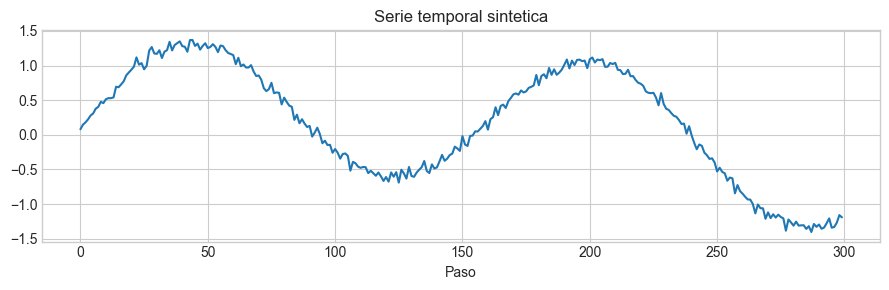

In [2]:
series_length = int(choose_value(2600, 1200))
points = np.linspace(0, 32 * np.pi, series_length)
series = np.sin(points) + 0.35 * np.sin(points / 2.5) + 0.1 * np.cos(points / 7)
series += np.random.default_rng(29).normal(0, 0.05, size=series_length)

window_size = 24

def build_windows(values: np.ndarray, window: int) -> tuple[np.ndarray, np.ndarray]:
    X_windows = []
    y_next = []
    for start in range(len(values) - window):
        X_windows.append(values[start : start + window])
        y_next.append(values[start + window])
    return np.array(X_windows, dtype='float32'), np.array(y_next, dtype='float32')

X_seq, y_seq = build_windows(series, window=window_size)
train_end = int(len(X_seq) * 0.7)
val_end = int(len(X_seq) * 0.85)

X_train = torch.tensor(X_seq[:train_end]).unsqueeze(-1)
y_train = torch.tensor(y_seq[:train_end]).unsqueeze(-1)
X_val = torch.tensor(X_seq[train_end:val_end]).unsqueeze(-1)
y_val = torch.tensor(y_seq[train_end:val_end]).unsqueeze(-1)
X_test = torch.tensor(X_seq[val_end:]).unsqueeze(-1)
y_test = torch.tensor(y_seq[val_end:]).unsqueeze(-1)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=int(choose_value(64, 32)), shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=128)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=128)

plt.figure(figsize=(9, 3))
plt.plot(series[:300])
plt.title('Serie temporal sintetica')
plt.xlabel('Paso')
plt.tight_layout()
        


In [6]:
class RecurrentRegressor(torch.nn.Module):
    def __init__(self, kind: str, hidden_size: int = 32) -> None:
        super().__init__()
        if kind == 'rnn':
            self.core = torch.nn.RNN(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif kind == 'lstm':
            self.core = torch.nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif kind == 'gru':
            self.core = torch.nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        else:
            raise ValueError(kind)
        self.head = torch.nn.Linear(hidden_size, 1)

    def forward(self, sequence: torch.Tensor) -> torch.Tensor:
        outputs, hidden = self.core(sequence)
        if isinstance(hidden, tuple):
            hidden_state = hidden[0][-1]
        else:
            hidden_state = hidden[-1]
        return self.head(hidden_state)


class TemporalCNN(torch.nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Conv1d(1, 16, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(16, 32, kernel_size=3, padding=1),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.head = torch.nn.Linear(32, 1)

    def forward(self, sequence: torch.Tensor) -> torch.Tensor:
        x = sequence.transpose(1, 2)
        x = self.network(x).squeeze(-1)
        return self.head(x)


def evaluate_regression_model(model: torch.nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    mse = torch.nn.MSELoss()
    with torch.inference_mode():
        for features, targets in loader:
            features = features.to(runtime.device)
            targets = targets.to(runtime.device)
            total_loss += mse(model(features), targets).item() * len(features)
    return total_loss / len(loader.dataset)


def train_sequence_model(name: str, model: torch.nn.Module) -> dict:
    model = model.to(runtime.device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
    mse = torch.nn.MSELoss()
    epochs = int(choose_value(20, 6))
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for features, targets in train_loader:
            features = features.to(runtime.device)
            targets = targets.to(runtime.device)
            optimizer.zero_grad()
            preds = model(features)
            loss = mse(preds, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(features)

        history['train_loss'].append(running_loss / len(train_loader.dataset))
        history['val_loss'].append(evaluate_regression_model(model, val_loader))

    test_mse = evaluate_regression_model(model, test_loader)
    return {'name': name, 'history': history, 'test_mse': test_mse, 'model': model}


sequence_results = [
    train_sequence_model('RNN', RecurrentRegressor('rnn')),
    train_sequence_model('LSTM', RecurrentRegressor('lstm')),
    train_sequence_model('GRU', RecurrentRegressor('gru')),
    train_sequence_model('TemporalCNN', TemporalCNN()),
]

for result in sequence_results:
    print({'modelo': result['name'], 'test_mse': round(result['test_mse'], 4)})
        


{'modelo': 'RNN', 'test_mse': 0.0034}
{'modelo': 'LSTM', 'test_mse': 0.0033}
{'modelo': 'GRU', 'test_mse': 0.0042}
{'modelo': 'TemporalCNN', 'test_mse': 0.0057}


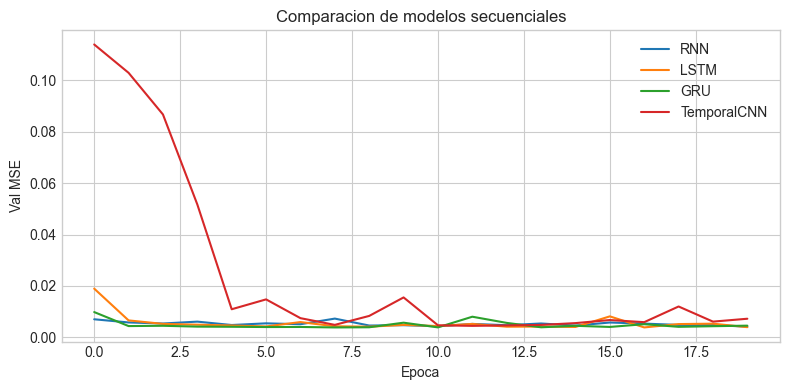

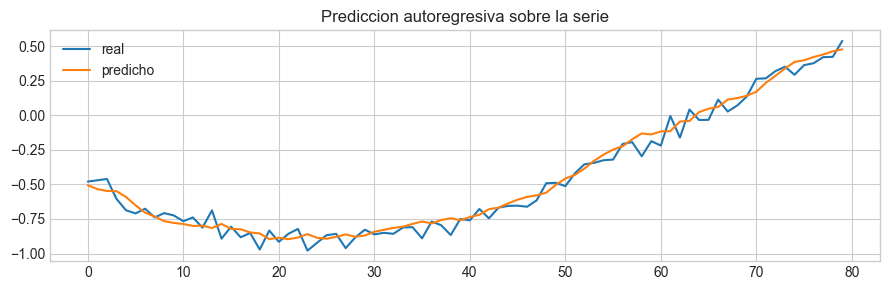

In [7]:
plt.figure(figsize=(8, 4))
for result in sequence_results:
    plt.plot(result['history']['val_loss'], label=result['name'])
plt.title('Comparacion de modelos secuenciales')
plt.xlabel('Epoca')
plt.ylabel('Val MSE')
plt.legend()
plt.tight_layout()

best_sequence_model = min(sequence_results, key=lambda item: item['test_mse'])['model']
with torch.inference_mode():
    preds = best_sequence_model(X_test[:80].to(runtime.device)).cpu().squeeze().numpy()

plt.figure(figsize=(9, 3))
plt.plot(y_test[:80].squeeze().numpy(), label='real')
plt.plot(preds, label='predicho')
plt.title('Prediccion autoregresiva sobre la serie')
plt.legend()
plt.tight_layout()
        


In [8]:
corpus_sentences = [sentence.strip() for sentence in load_corpus_text().split('.') if len(sentence.strip().split()) > 6][:4]
tokenized = [simple_tokenize(sentence) for sentence in corpus_sentences]
flat_tokens = [token for sentence in tokenized for token in sentence]
vocab = build_vocabulary(flat_tokens)
encoded = [torch.tensor(vocab.encode(tokens), dtype=torch.long) for tokens in tokenized]
padded = pad_sequence(encoded, batch_first=True, padding_value=vocab.stoi['<pad>'])
lengths = [len(item) for item in encoded]

print({'sentencias': corpus_sentences[:2], 'lengths': lengths, 'padded_shape': tuple(padded.shape)})
print('Ejemplo de primera fila padding-aware:', padded[0][:12].tolist())
        


{'sentencias': ['dicen los narradores antiguos que habia un rey poderoso que, herido por la traicion, habia jurado no confiar mas en ninguna mujer del reino', 'cada noche ordenaba que llevaran a su palacio a una joven distinta, y al amanecer la hacia apartar de su vista como si la noche no hubiera dejado memoria ni deber'], 'lengths': [26, 32, 32, 13], 'padded_shape': (4, 32)}
Ejemplo de primera fila padding-aware: [25, 45, 51, 9, 62, 34, 72, 64, 60, 62, 4, 36]


## Para cerrar

### Ideas clave

- la compuerta existe para administrar memoria,
- la recurrencia modela orden de forma natural pero pierde paralelismo,
- una CNN temporal puede ser muy competitiva cuando el patron relevante cabe en una ventana local,
- el padding no es un detalle: es parte del contrato entre datos y modelo.

### Pruebas sugeridas

- aumenta `window_size` y mira si la CNN mejora,
- fuerza mas ruido en la serie y compara robustez,
- toma fragmentos mas largos del corpus y observa como crece el padding.
